In [67]:
#%matplotlib qt5
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
# from matplotlib import rcParams

# rcParams.update({
#     'font.size': 14, 'grid.alpha': 0.5, 'grid.linestyle': '--',
#     'axes.grid': True,
# })

# Pymodels

Python module for accelerator modelling

### Accelerator Models

- Linac: li
- Transport Line - Linac to Booster: tb
- Booster: bo
- Transport Line - Booster to Sirius: ts
- Sirius (Storage Ring): si

In [68]:
import pymodels

In [69]:
model = pymodels.si.create_accelerator()
model.cavity_on = False
model.radiation_on = False
model.vchamber_on = False

In [70]:
print(model)
print()
print(model[10])

energy         : 3000000000.0 eV
harmonic_number: 864
cavity_on      : False
radiation_on   : 0
vchamber_on    : False
lattice version: SI_V25_04_1.21.3
lattice size   : 6752
lattice length : 518.3898999999917 m

fam_name   : SVVC 
pass_method: identity_pass 
vchamber   : 2 
hmin       : -0.0145 m
hmax       : 0.0145 m
vmin       : -0.00475 m
vmax       : 0.00475 m


**Family** = A set of objects of exactly same type. 

Examples:
- Central Dipoles (BC)
- Focusing quadrupoles in high beta segments (QFA)
- Beam Position Monitors (BPM)

Getting data about families:

In [71]:
# fam_name with devname, index, subsection
famdata = pymodels.si.get_family_data(model)

In [72]:
print(famdata['BC']['index'][0])
print(np.shape(famdata['BC']['index']))

print(model[152])

[152, 153, 154, 156, 157, 158, 160, 161, 163, 164, 165, 166, 167, 168, 169, 170, 171, 174, 175, 176, 177, 178, 179, 180, 181, 182, 184, 185, 187, 188, 189, 191, 192, 193]
(20, 34)
fam_name   : BC 
pass_method: bnd_mpole_symplectic4_pass 
length     : 0.035 m
angle      : 0.0002345722514680379 rad
polynom_b  : [ 0.0000e+00 -1.9828e-02 -1.2534e+00  1.9342e+01  2.8084e+03 -2.9546e+05
 -5.0640e+07  1.4694e+09  4.0940e+11  0.0000e+00 -1.2172e+15] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


['01BC', '02BC', '03BC', '04BC', '05BC', '06BC', '07BC', '08BC', '09BC', '10BC', '11BC', '12BC', '13BC', '14BC', '15BC', '16BC', '17BC', '18BC', '19BC', '20BC']
(20, 34)


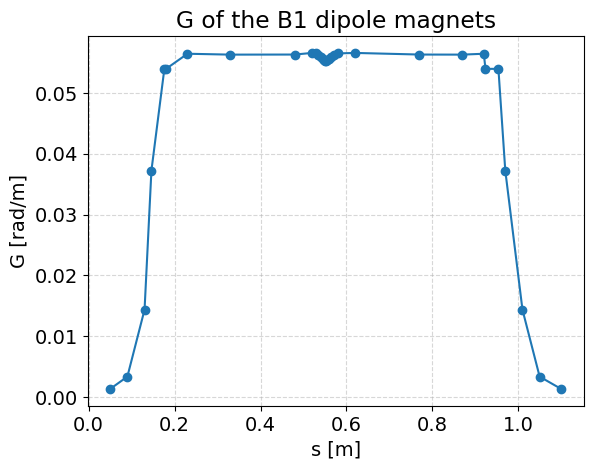

In [73]:
print(famdata['BC']['subsection'])
print(np.shape(famdata['BC']['index']))

fullB1 = [model[idx] for idx in famdata['B1']['index'][1]]
G = [elem.angle/elem.length for elem in fullB1]
s = np.cumsum([e.length for e in fullB1])

plt.figure()
plt.plot(s, G, 'o-')
plt.xlabel('s [m]')
plt.ylabel('G [rad/m]')
plt.title('G of the B1 dipole magnets')
plt.show()

(20, 46)
Total bending angle of the B1 dipole magnets: 0.04809 rad = 2.755 deg
Total bending angle of the B2 dipole magnets: 0.07150 rad = 4.096 deg
Total bending angle of the BC dipole magnets: 0.07499 rad = 4.297 deg


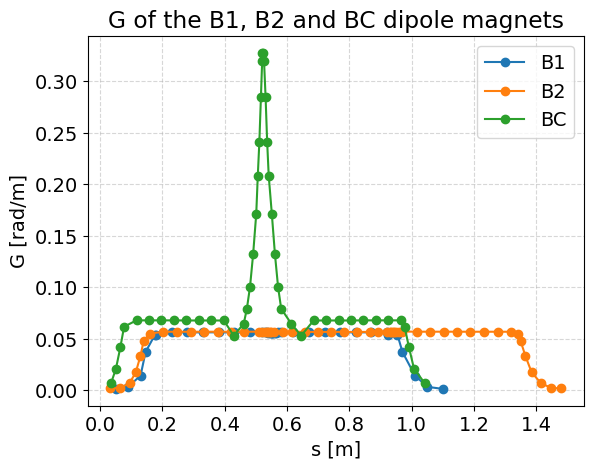

In [74]:
import pyaccel
model1 = pyaccel.lattice.refine_lattice(model)
famdata1 = pymodels.si.get_family_data(model1)
print(np.shape(famdata1['BC']['index']))


fullB1 = [model1[idx] for idx in famdata1['B1']['index'][1]]
thetaB1 = np.sum([elem.angle for elem in fullB1])
print(f'Total bending angle of the B1 dipole magnets: {thetaB1:.5f} rad = {thetaB1*180/np.pi:.3f} deg')
G_B1 = [elem.angle/elem.length if elem.length != 0 else 0 for elem in fullB1]
s_B1 = np.cumsum([e.length for e in fullB1])

fullB2 = [model1[idx] for idx in famdata1['B2']['index'][1]]
thetaB2 = np.sum([elem.angle for elem in fullB2])
print(f'Total bending angle of the B2 dipole magnets: {thetaB2:.5f} rad = {thetaB2*180/np.pi:.3f} deg')
G_B2 = [elem.angle/elem.length if elem.length != 0 else 0 for elem in fullB2]
s_B2 = np.cumsum([e.length for e in fullB2])

fullBC = [model1[idx] for idx in famdata1['BC']['index'][1]]
thetaBC = np.sum([elem.angle for elem in fullBC])
print(f'Total bending angle of the BC dipole magnets: {thetaBC:.5f} rad = {thetaBC*180/np.pi:.3f} deg')
G_BC = [elem.angle/elem.length if elem.length != 0 else 0 for elem in fullBC]
s_BC = np.cumsum([e.length for e in fullBC])


plt.figure()
plt.plot(s_B1, G_B1, 'o-', label='B1')
plt.plot(s_B2, G_B2, 'o-', label='B2')
plt.plot(s_BC, G_BC, 'o-', label='BC')
plt.xlabel('s [m]')
plt.ylabel('G [rad/m]')
plt.title('G of the B1, B2 and BC dipole magnets')
plt.legend()
plt.show()

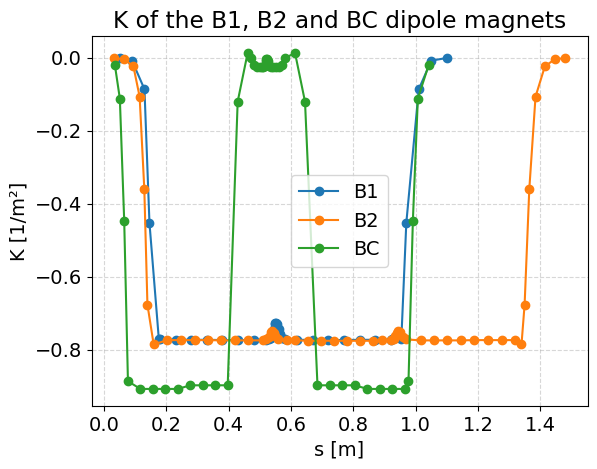

In [75]:
fullB1 = [model1[idx] for idx in famdata1['B1']['index'][1]]
K_B1 = [elem.K for elem in fullB1]
s_B1 = np.cumsum([e.length for e in fullB1])

fullB2 = [model1[idx] for idx in famdata1['B2']['index'][1]]
K_B2 = [elem.K for elem in fullB2]
s_B2 = np.cumsum([e.length for e in fullB2])

fullBC = [model1[idx] for idx in famdata1['BC']['index'][1]]
K_BC = [elem.K for elem in fullBC]
s_BC = np.cumsum([e.length for e in fullBC])

plt.figure()
plt.plot(s_B1, K_B1, 'o-', label='B1')
plt.plot(s_B2, K_B2, 'o-', label='B2')
plt.plot(s_BC, K_BC, 'o-', label='BC')
plt.xlabel('s [m]')
plt.ylabel('K [1/m²]')
plt.title('K of the B1, B2 and BC dipole magnets')
plt.legend()
plt.show()

In [76]:
print(famdata1['QFA']['index'][0])
quad = model1[famdata1['QFA']['index'][0][1]]
print(f'K1 QFA = {quad.K:.3f} 1/m²')

print(f'K1 B1 = {model1[famdata1["B1"]["index"][0][20]].K:.3f} 1/m²')
print(f'K1 B2 = {model1[famdata1["B2"]["index"][0][20]].K:.3f} 1/m²')

[89, 90, 91, 92]
K1 QFA = 3.573 1/m²
K1 B1 = -0.730 1/m²
K1 B2 = -0.763 1/m²


In [77]:
bcidx = famdata['BC']['index']

In [78]:
bcidx

[[152,
  153,
  154,
  156,
  157,
  158,
  160,
  161,
  163,
  164,
  165,
  166,
  167,
  168,
  169,
  170,
  171,
  174,
  175,
  176,
  177,
  178,
  179,
  180,
  181,
  182,
  184,
  185,
  187,
  188,
  189,
  191,
  192,
  193],
 [489,
  490,
  491,
  493,
  494,
  495,
  497,
  498,
  500,
  501,
  502,
  503,
  504,
  505,
  506,
  507,
  508,
  511,
  512,
  513,
  514,
  515,
  516,
  517,
  518,
  519,
  521,
  522,
  524,
  525,
  526,
  528,
  529,
  530],
 [824,
  825,
  826,
  828,
  829,
  830,
  832,
  833,
  835,
  836,
  837,
  838,
  839,
  840,
  841,
  842,
  843,
  846,
  847,
  848,
  849,
  850,
  851,
  852,
  853,
  854,
  856,
  857,
  859,
  860,
  861,
  863,
  864,
  865],
 [1160,
  1161,
  1162,
  1164,
  1165,
  1166,
  1168,
  1169,
  1171,
  1172,
  1173,
  1174,
  1175,
  1176,
  1177,
  1178,
  1179,
  1182,
  1183,
  1184,
  1185,
  1186,
  1187,
  1188,
  1189,
  1190,
  1192,
  1193,
  1195,
  1196,
  1197,
  1199,
  1200,
  1201],
 [1492,
  

In [79]:
np.shape(famdata['BC']['index'])

(20, 34)

Some families have devnames keys:

In [80]:
famdata['BPM']['devnames']

['SI-01M2:DI-BPM',
 'SI-01C1:DI-BPM-1',
 'SI-01C1:DI-BPM-2',
 'SI-01C2:DI-BPM',
 'SI-01C3:DI-BPM-1',
 'SI-01C3:DI-BPM-2',
 'SI-01C4:DI-BPM',
 'SI-02M1:DI-BPM',
 'SI-02M2:DI-BPM',
 'SI-02C1:DI-BPM-1',
 'SI-02C1:DI-BPM-2',
 'SI-02C2:DI-BPM',
 'SI-02C3:DI-BPM-1',
 'SI-02C3:DI-BPM-2',
 'SI-02C4:DI-BPM',
 'SI-03M1:DI-BPM',
 'SI-03M2:DI-BPM',
 'SI-03C1:DI-BPM-1',
 'SI-03C1:DI-BPM-2',
 'SI-03C2:DI-BPM',
 'SI-03C3:DI-BPM-1',
 'SI-03C3:DI-BPM-2',
 'SI-03C4:DI-BPM',
 'SI-04M1:DI-BPM',
 'SI-04M2:DI-BPM',
 'SI-04C1:DI-BPM-1',
 'SI-04C1:DI-BPM-2',
 'SI-04C2:DI-BPM',
 'SI-04C3:DI-BPM-1',
 'SI-04C3:DI-BPM-2',
 'SI-04C4:DI-BPM',
 'SI-05M1:DI-BPM',
 'SI-05M2:DI-BPM',
 'SI-05C1:DI-BPM-1',
 'SI-05C1:DI-BPM-2',
 'SI-05C2:DI-BPM',
 'SI-05C3:DI-BPM-1',
 'SI-05C3:DI-BPM-2',
 'SI-05C4:DI-BPM',
 'SI-06M1:DI-BPM',
 'SI-06M2:DI-BPM',
 'SI-06C1:DI-BPM-1',
 'SI-06C1:DI-BPM-2',
 'SI-06C2:DI-BPM',
 'SI-06C3:DI-BPM-1',
 'SI-06C3:DI-BPM-2',
 'SI-06C4:DI-BPM',
 'SI-07M1:DI-BPM',
 'SI-07M2:DI-BPM',
 'SI-07C1:DI-BPM-1',


Finding out the families names

In [81]:
pymodels.si.families.families_pulsed_magnets()

['InjDpKckr', 'InjNLKckr', 'PingH', 'PingV']

In [82]:
pymodels.si.families.families_dipoles()

['B1', 'B2', 'BC']

In [83]:
pymodels.si.families.families_quadrupoles()

['QFA',
 'QDA',
 'QFB',
 'QDB1',
 'QDB2',
 'QFP',
 'QDP1',
 'QDP2',
 'Q1',
 'Q2',
 'Q3',
 'Q4']

In [84]:
Q1_1 = model[famdata['Q1']['index'][0][0]]
print(Q1_1)

fam_name   : Q1 
pass_method: str_mpole_symplectic4_pass 
length     : 0.2 m
nr_steps   : 14 
polynom_b  : [ 0.00000000e+00  2.81837060e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -5.00052674e+04  0.00000000e+00  0.00000000e+00
  0.00000000e+00  1.08810511e+13  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -2.06323755e+20] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


In [85]:
famdata['QFA']['index']

[[18], [1334], [1358], [2680], [2702], [4028], [4052], [5380], [5404], [6729]]

In [86]:
pymodels.si.families.families_sextupoles()

['SDA0',
 'SDB0',
 'SDP0',
 'SDA1',
 'SDB1',
 'SDP1',
 'SDA2',
 'SDB2',
 'SDP2',
 'SDA3',
 'SDB3',
 'SDP3',
 'SFA0',
 'SFB0',
 'SFP0',
 'SFA1',
 'SFB1',
 'SFP1',
 'SFA2',
 'SFB2',
 'SFP2']

In [87]:
# Diagnostic families
pymodels.si.families.families_di()

['BPM',
 'IDBPM',
 'DCCT',
 'ScrapH',
 'ScrapV',
 'GSL15',
 'GSL07',
 'GBPM',
 'BbBPkup',
 'BbBKckrH',
 'BbBKckrV',
 'BbBKckrL',
 'TuneShkrH',
 'TuneShkrV',
 'TunePkupH',
 'TunePkupV']

Extracting PVs information

In [88]:
from siriuspy.epics import PV

In [89]:
# Instantiating the first BPM PV whose measures the x position of the beam.
bpm1 = PV(famdata['BPM']['devnames'][3]+':PosY-Mon')

In [90]:
bpm1.get()

58852.339030700736

### Elements Types
markers, drifts, dipoles, quadrupoles, sextupoles, cavity

In [91]:
# Marker
print(model[0])

fam_name   : start 
pass_method: identity_pass 
hmin       : -0.022 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


In [92]:
# Drift
print(model[2])

fam_name   : lkkp 
pass_method: drift_pass 
length     : 1.9148475000000014 m
hmin       : -0.022 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


In [93]:
# 20 BC dipoles divided in 34 segments
bc_idx = famdata['BC']['index']
np.array(bc_idx).shape

(20, 34)

In [94]:
bc_elem = model[bc_idx[0][2]]
print(bc_elem) 
# Pay attention at the angle property:

fam_name   : BC 
pass_method: bnd_mpole_symplectic4_pass 
length     : 0.014 m
angle      : 0.0005827654372409067 rad
polynom_b  : [ 0.0000e+00 -4.4684e-01 -1.8750e+00  2.2077e+01 -5.5912e+03 -1.6748e+05
  1.0327e+08  9.3221e+08 -8.6332e+11  0.0000e+00  2.7550e+15] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


In [95]:
# quadrupole
q1_idx = famdata['Q1']['index']
np.array(q1_idx).shape

(40, 1)

In [96]:
print(model[q1_idx[0][0]])

fam_name   : Q1 
pass_method: str_mpole_symplectic4_pass 
length     : 0.2 m
nr_steps   : 14 
polynom_b  : [ 0.00000000e+00  2.81837060e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -5.00052674e+04  0.00000000e+00  0.00000000e+00
  0.00000000e+00  1.08810511e+13  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -2.06323755e+20] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


In [97]:
# quadrupole skew
qs_idx = famdata['QS']['index']
np.array(qs_idx).shape

(100, 1)

In [98]:
qs_elem = model[qs_idx[0][0]]
print(qs_elem)

fam_name   : SFA0 
pass_method: str_mpole_symplectic4_pass 
length     : 0.15 m
nr_steps   : 10 
polynom_b  : [ 0.      0.     52.5696] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


In [99]:
q1_elem = model[q1_idx[0][0]]
print(q1_elem)

fam_name   : Q1 
pass_method: str_mpole_symplectic4_pass 
length     : 0.2 m
nr_steps   : 14 
polynom_b  : [ 0.00000000e+00  2.81837060e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -5.00052674e+04  0.00000000e+00  0.00000000e+00
  0.00000000e+00  1.08810511e+13  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -2.06323755e+20] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


Extracting the KL term of an element

In [100]:
q1_elem.KL

0.5636741202576

In [101]:
q1_elem.polynom_b[1]*q1_elem.length

0.5636741202576

In [102]:
# sextupole
sfa0_idx = famdata['SFA0']['index']
np.array(sfa0_idx).shape

(10, 1)

In [103]:
sfa0_elem = model[sfa0_idx[0][0]]
print(sfa0_elem)

fam_name   : SFA0 
pass_method: str_mpole_symplectic4_pass 
length     : 0.15 m
nr_steps   : 10 
polynom_b  : [ 0.      0.     52.5696] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


Extracting the SL term of an element

In [104]:
sfa0_elem.SL, sfa0_elem.polynom_b[2]*sfa0_elem.length

(7.88544, 7.88544)

In [105]:
cav_idx = famdata['SRFCav']['index']
cav_elem = model[cav_idx[0][0]]
print(cav_elem)

fam_name   : SRFCav 
pass_method: cavity_pass 
frequency  : 499663831.62944365 Hz
voltage    : 3000000.0 V
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


# Pyaccel

Python module for beam dynamics tracking and optics calculations

accelerator, elements, lattice, optics, tracking

In [106]:
import pyaccel

### Model manipulation

Getting the $s$ coordinate of all elements in the lattice:

In [107]:
spos = pyaccel.lattice.find_spos(model)
spos[bc_idx[0]]

array([12.4387475, 12.4737475, 12.4897475, 12.5037475, 12.5157475,
       12.6757475, 12.8357475, 12.8677475, 12.8997475, 12.9097475,
       12.9197475, 12.9297475, 12.9397475, 12.9447475, 12.9497475,
       12.9547475, 12.9587475, 12.9597475, 12.9607475, 12.9647475,
       12.9697475, 12.9747475, 12.9797475, 12.9897475, 12.9997475,
       13.0097475, 13.0197475, 13.0517475, 13.0837475, 13.2437475,
       13.4037475, 13.4157475, 13.4297475, 13.4457475])

Finding indexes of an family present in the model.

In [108]:
cav_idx = pyaccel.lattice.find_indices(lattice=model, attribute_name='fam_name', value='SRFCav')
cav_idx, famdata['SRFCav']['index']

([677], [[677]])

Getting an attribute

In [109]:
rf_freq = pyaccel.lattice.get_attribute(model, 'frequency', indices=cav_idx)
rf_freq, model[cav_idx[0]].frequency

(499663831.62944365, 499663831.62944365)

Setting an attribute

In [110]:
pyaccel.lattice.set_attribute(model, 'frequency', indices=cav_idx, values=rf_freq+100)
model[cav_idx[0]].frequency

499663931.62944365

Setting and getting attributes using python property short command: 

In [111]:
model[cav_idx[0]].frequency = rf_freq
model[cav_idx[0]].frequency

499663831.62944365

Change all quadrupoles forces

In [112]:
# default_KL = model[q1_idx[0][0]].KL

In [113]:
# pyaccel.lattice.set_attribute(model, 'KL', indices=q1_idx, values=1.5 * default_KL)

### Optics functions

In [114]:
refined_model = pyaccel.lattice.refine_lattice(model)
twiss, *_ = pyaccel.optics.calc_twiss(refined_model)

## For coupled motion, you can use the Edwards-Teng functions:
#edteng,*_ = pyaccel.optics.calc_edwards_teng(refined_model)  

In [115]:
betax, betay = twiss.betax, twiss.betay  # Beta functions
etax, etay = twiss.etax, twiss.etay      # Dispersion functions
mux, muy = twiss.mux, twiss.muy          # Phase advance
spos = twiss.spos                        # s coordinate

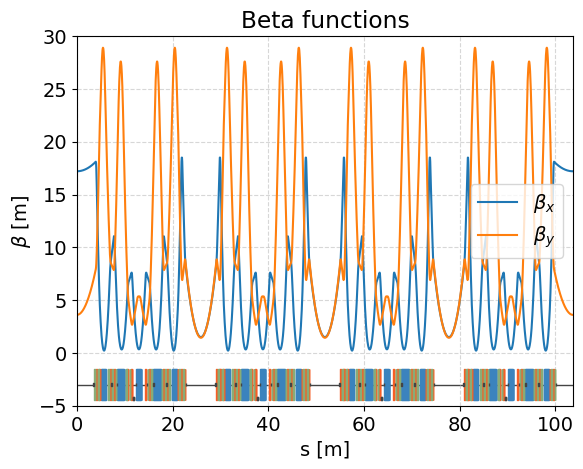

<Figure size 640x480 with 0 Axes>

In [116]:
plt.figure()
plt.plot(spos, betax, label=r'$\beta_x$')
plt.plot(spos, betay, label=r'$\beta_y$')
plt.xlabel('s [m]')
plt.ylabel(r'$\beta$ [m]')
plt.title('Beta functions')
plt.xlim([0, refined_model.length/5])
plt.ylim([-5, 30])
plt.legend()
pyaccel.graphics.draw_lattice(refined_model, offset=-3, height=3, gca=True)
plt.tight_layout()
plt.show()

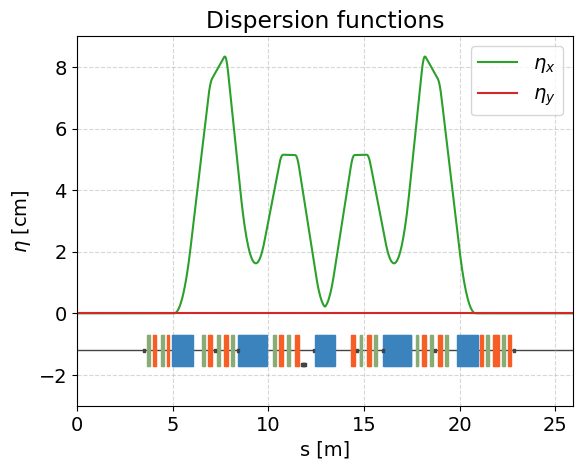

<Figure size 640x480 with 0 Axes>

In [117]:
plt.figure()
plt.plot(spos, etax*100, label=r'$\eta_x$', color='C2')
plt.plot(spos, etay*100, label=r'$\eta_y$', color='C3')
plt.xlabel('s [m]')
plt.ylabel(r'$\eta$ [cm]')
plt.title('Dispersion functions')
plt.xlim([0, model.length/20])
plt.ylim([-3, 9])
plt.legend()
pyaccel.graphics.draw_lattice(refined_model, offset=-1.2, height=1.0, gca=True)
plt.tight_layout()
plt.show()

In [118]:
# Tunes
mux[-1]/2/np.pi, muy[-1]/2/np.pi

(49.09597693477737, 14.151811222178912)

In [119]:
# Chromaticities
pyaccel.optics.get_chromaticities(refined_model)

(2.5399371719470043, 2.5212091951387627)

EdwardsTeng examples

In [120]:
edteng,*_ = pyaccel.optics.calc_edwards_teng(refined_model)

In [121]:
C, emit_ratio = pyaccel.optics.estimate_coupling_parameters(edteng)

In [122]:
C

0.0

### Equilibrium Parameters

In [123]:
# eqparam = pyaccel.optics.EquilibriumParametersIntegrals(refined_model)
eqparam = pyaccel.optics.EqParamsFromBeamEnvelope(refined_model)

In [124]:
print(eqparam)

Energy [GeV]                    : 3
Energy offset [%]               : 0
J1, J2, J3                      : 1.299, 1, 1.701
tau1, tau2, tau3 [ms]           : 16.81, 21.85, 12.85
alpha1, alpha2, alpha3 [Hz]     : 59.48, 45.77, 77.84
tune1, tune2, tune3 [Hz]        : 0.09599, 0.1518, 0.004713
momentum compaction x 1e4       : 1.636
energy loss [keV]               : 474.9
overvoltage                     : 6.317
sync phase [°]                  : 170.9
mode 1 emittance [nm.rad]       : 0.2493
mode 2 emittance [pm.rad]       : 1.607e-25
natural espread [%]             : 0.08511
bunch length [mm]               : 2.437
RF energy accep. [%]            : 5.866


In [125]:
# Momentum Compaction Factor
eqparam.alpha, pyaccel.optics.get_mcf(refined_model)

(0.00016360388336303944, 0.00016357573749564984)

In [126]:
# Emittances
eqparam.emit1, eqparam.emit2, eqparam.emit3

(2.492615159581898e-10, 1.6065709142375099e-37, 2.074231205542077e-06)

In [127]:
# Energy spread, Bunch length
eqparam.espread0, eqparam.bunlen

(0.0008511126764794506, 0.00243722760788632)

In [128]:
# Damping times
eqparam.tau1, eqparam.tau2, eqparam.tau3

(0.01681326843138171, 0.021847111630683216, 0.012846683848582776)

### One-turn matrix

In [129]:
m1turn = pyaccel.tracking.find_m44(refined_model)

In [130]:
np.linalg.det(m1turn)

0.9999999999999205

### Closed orbit

$r = [x, x', y, y', \delta, z]^T$

idx = [0, 1, 2, 3, 4, 5]

In [131]:
model = pymodels.si.create_accelerator()
model.cavity_on = True

In [132]:
cod = pyaccel.tracking.find_orbit6(model, indices='open')
cod.shape

(6, 6752)

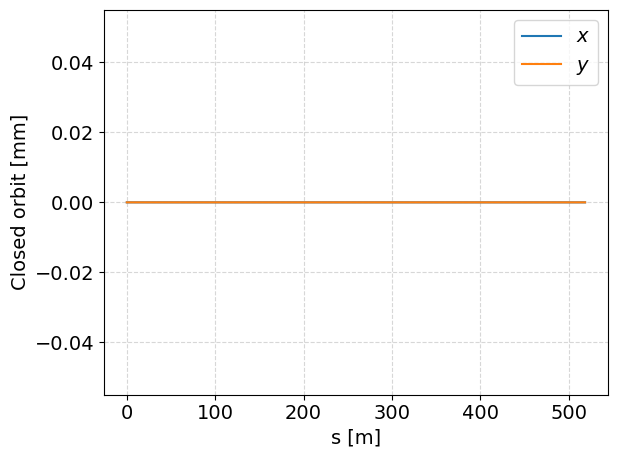

In [133]:
plt.figure()
spos = pyaccel.lattice.find_spos(model)
plt.plot(spos, cod[0, :]*1e3, label=r'$x$')
plt.plot(spos, cod[2, :]*1e3, label=r'$y$')
plt.xlabel('s [m]')
plt.ylabel(r'Closed orbit [mm]')
plt.legend()
plt.tight_layout()
plt.show()

In [134]:
chidx = famdata['CH']['index'][0][0]
model[chidx].hkick_polynom = 10e-6 # [rad]
codx = pyaccel.tracking.find_orbit6(model, indices='open')
model[chidx].hkick_polynom = 0 # [rad]

cvidx = famdata['CV']['index'][0][0]
model[cvidx].vkick_polynom = 10e-6 # [rad]
cody = pyaccel.tracking.find_orbit6(model, indices='open')
model[cvidx].vkick_polynom = 0 # [rad]

cavidx = famdata['SRFCav']['index'][0][0]
model[cavidx].frequency += 100 # [Hz]
codrf = pyaccel.tracking.find_orbit6(model, indices='open')
model[cavidx].frequency -= 100 # [Hz]

bpmidx = famdata['BPM']['index']
bpmidx = np.array(bpmidx).ravel()

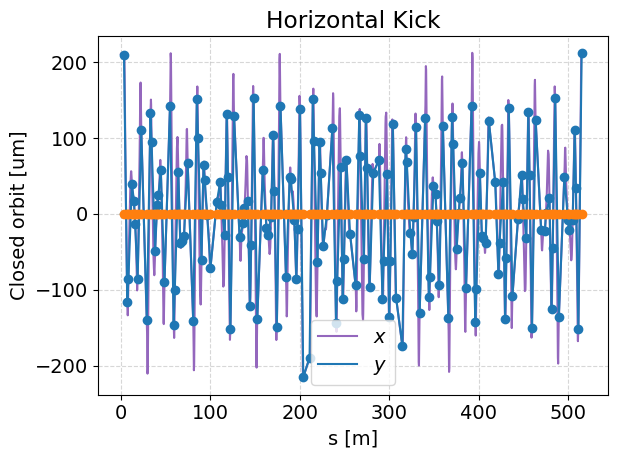

In [135]:
plt.figure()
spos = pyaccel.lattice.find_spos(model)
plt.plot(spos, codx[0, :]*1e6, label=r'$x$', color='C4')
plt.plot(spos[bpmidx], codx[0, bpmidx]*1e6, '-o', color='C0')
plt.plot(spos, codx[2, :]*1e6, label=r'$y$')
plt.plot(spos[bpmidx], codx[2, bpmidx]*1e6, '-o', color='C1')

plt.xlabel('s [m]')
plt.ylabel(r'Closed orbit [um]')
plt.title('Horizontal Kick')
plt.legend()
plt.tight_layout()
plt.show()

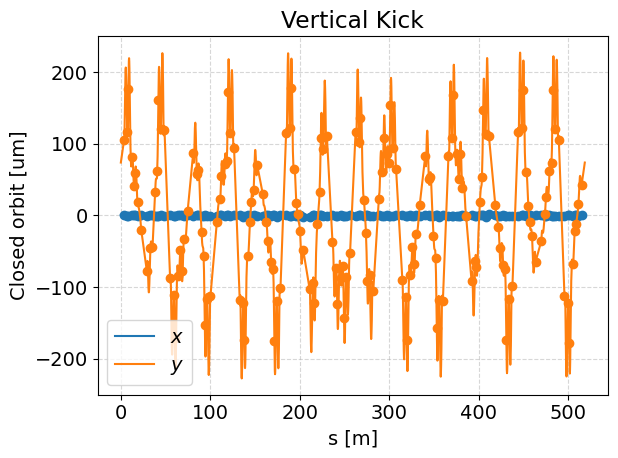

In [136]:
plt.figure()
spos = pyaccel.lattice.find_spos(model)
plt.plot(spos, cody[0, :]*1e6, label=r'$x$')
plt.plot(spos[bpmidx], cody[0, bpmidx]*1e6, 'o', color='C0')
plt.plot(spos, cody[2, :]*1e6, label=r'$y$')
plt.plot(spos[bpmidx], cody[2, bpmidx]*1e6, 'o', color='C1')
plt.xlabel('s [m]')
plt.ylabel(r'Closed orbit [um]')
plt.title('Vertical Kick')
plt.legend()
plt.tight_layout()
plt.show()

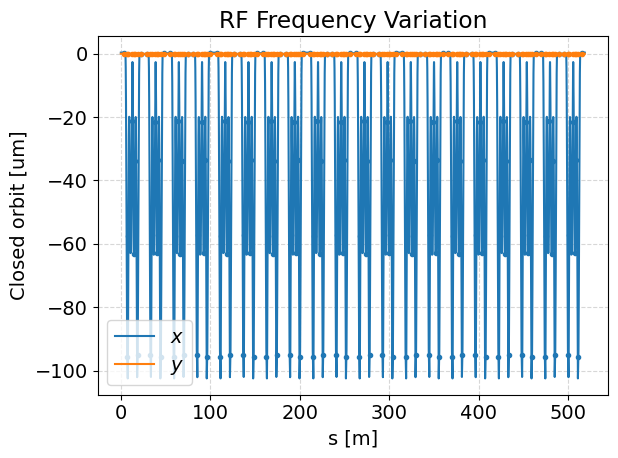

In [137]:
plt.figure()
spos = pyaccel.lattice.find_spos(model)
plt.plot(spos, codrf[0, :]*1e6, label=r'$x$')
plt.plot(spos[bpmidx], codrf[0, bpmidx]*1e6, '.', color='C0')
plt.plot(spos, codrf[2, :]*1e6, label=r'$y$')
plt.plot(spos[bpmidx], codrf[2, bpmidx]*1e6, '.', color='C1')
plt.xlabel('s [m]')
plt.ylabel(r'Closed orbit [um]')
plt.title('RF Frequency Variation')
plt.legend()
plt.tight_layout()
plt.show()

### Tracking

In [139]:
model = pymodels.si.create_accelerator()
model.cavity_on = False
model.radiation_on = False
model.vchamber_on = True

In [140]:
x0 = 100e-6
y0 = 1e-6
# nturns = 100

coord_ini = np.array([x0, 0, y0, 0, 0, 0])
coord_fin, *_ = pyaccel.tracking.line_pass(model, coord_ini, indices='open')

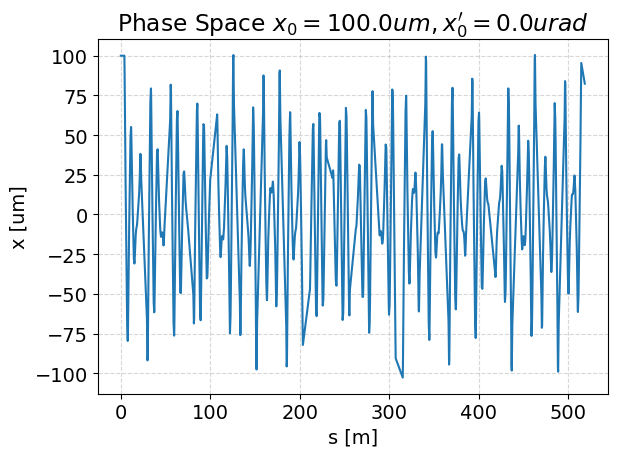

In [141]:
plt.figure()
spos = pyaccel.lattice.find_spos(model)

label = f"$x_0={coord_ini[0]*1e6:.1f}um, x_0'={coord_ini[1]*1e6:.1f}urad$"
plt.plot(spos, coord_fin[0, :]*1e6, ls='-')
plt.xlabel('s [m]')
plt.ylabel("x [um]")
plt.title('Phase Space ' + label)
plt.tight_layout()
plt.show()

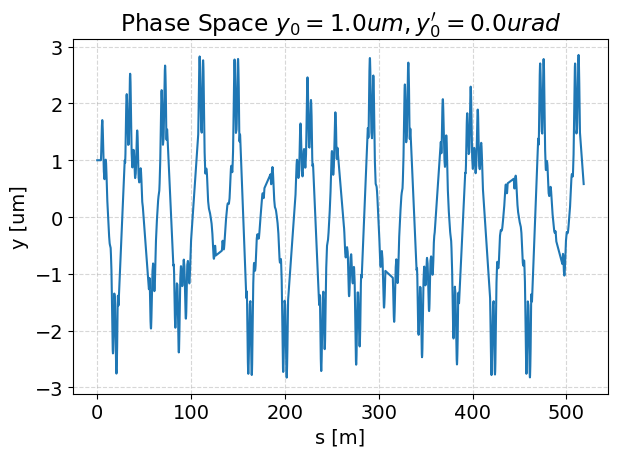

In [142]:
plt.figure()
spos = pyaccel.lattice.find_spos(model)

label = f"$y_0={coord_ini[2]*1e6:.1f}um, y_0'={coord_ini[3]*1e6:.1f}urad$"
plt.plot(spos, coord_fin[2, :]*1e6, ls='-')
plt.xlabel('s [m]')
plt.ylabel("y [um]")
plt.title('Phase Space ' + label)
plt.tight_layout()
plt.show()

In [143]:
x0 = 1e-6
y0 = 1e-6
nturns = 2000

coord_ini = np.array([x0, 0, y0, 0, 0, 0])
coord_fin, *_ = pyaccel.tracking.ring_pass(model, coord_ini, nr_turns=nturns, turn_by_turn=True, parallel=True)

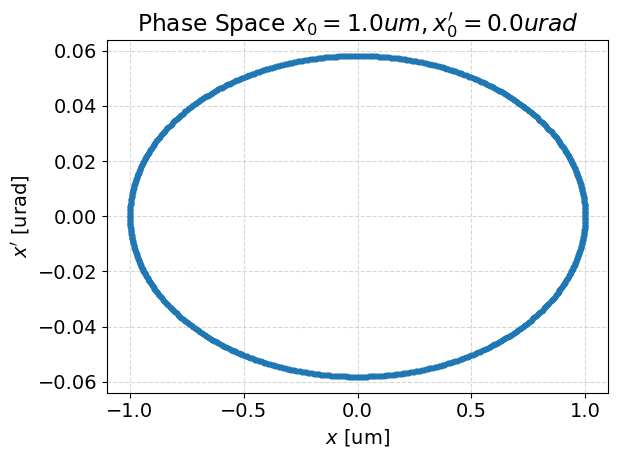

In [144]:
plt.figure()

label = f"$x_0={coord_ini[0]*1e6:.1f}um, x_0'={coord_ini[1]*1e6:.1f}urad$"
plt.plot(coord_fin[0, :]*1e6, coord_fin[1, :]*1e6, marker='.', ls='')
plt.xlabel('$x$ [um]')
plt.ylabel(r"$x'$ [urad]")
plt.title('Phase Space ' + label)
plt.tight_layout()
plt.show()

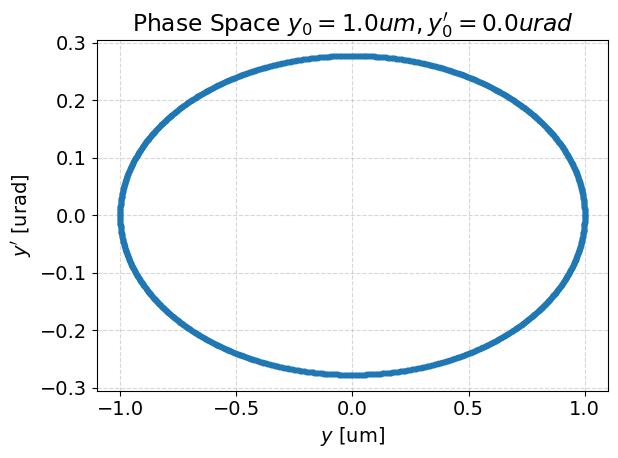

In [145]:
plt.figure()

label = f"$y_0={coord_ini[2]*1e6:.1f}um, y_0'={coord_ini[3]*1e6:.1f}urad$"
plt.plot(coord_fin[2, :]*1e6, coord_fin[3, :]*1e6, marker='.', ls='')
plt.xlabel('$y$ [um]')
plt.ylabel(r"$y'$ [urad]")
plt.title('Phase Space ' + label)
plt.tight_layout()
plt.show()

In [146]:
# Switch to 6D tracking
model.cavity_on = True
model.radiation_on = True
orb = pyaccel.tracking.find_orbit6(model, indices=None).ravel()

x0 = 5e-3
nturns = 5000

coord_ini = np.array([x0, 0, 1e-6, 0, 0, 0]) + orb
coord_fin, *_ = pyaccel.tracking.ring_pass(model, coord_ini, nr_turns=nturns, turn_by_turn=True, parallel=True)

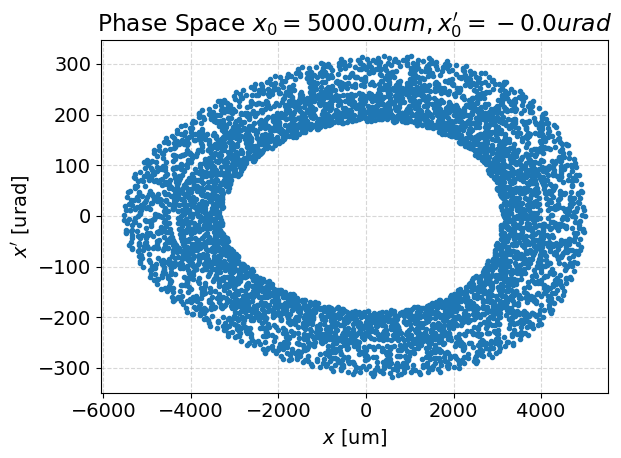

In [147]:
plt.figure()

label = f"$x_0={coord_ini[0]*1e6:.1f}um, x_0'={coord_ini[1]*1e6:.1f}urad$"
plt.plot(coord_fin[0, :]*1e6, coord_fin[1, :]*1e6, marker='.', ls='')
plt.xlabel('$x$ [um]')
plt.ylabel(r"$x'$ [urad]")
plt.title('Phase Space ' + label)
plt.tight_layout()
plt.show()

#### Tracking a bunch of particles

In [148]:
# 4D first then switch to 6D
model.cavity_on = False
model.radiation_on = False

In [149]:
emit1 = eqparam.emit1
emit2 = abs(eqparam.emit2)
espread = eqparam.espread0
bunlen = eqparam.bunlen
npart = 200

bunch = pyaccel.tracking.generate_bunch(
    emit1=emit1, emit2=emit2, sigmae=espread, sigmas=bunlen, optics=twiss[0], n_part=npart, cutoff=3)
bunch.shape

(6, 200)

In [150]:
nturns = 500
bunch_tbt, *_ = pyaccel.tracking.ring_pass(model, bunch, nr_turns=nturns, turn_by_turn=True, parallel=True)
bunch_tbt.shape

(6, 200, 501)

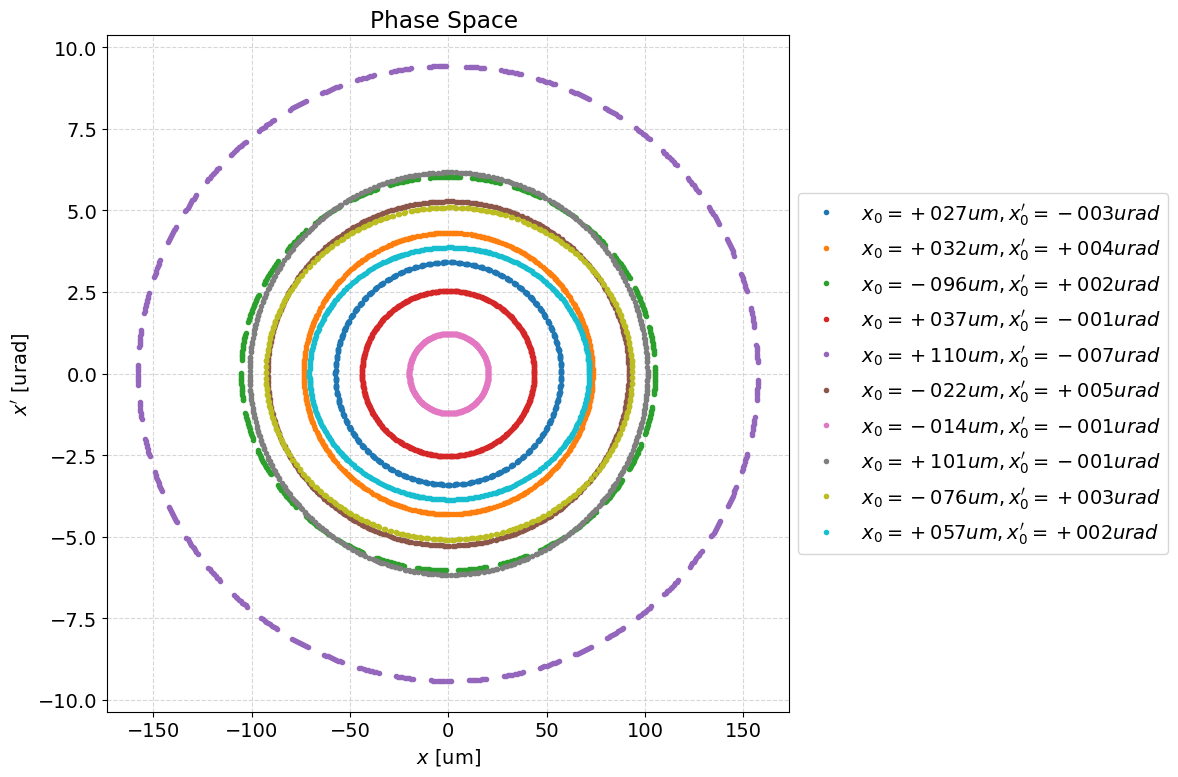

In [151]:
plt.figure(figsize=(12, 8))

for part in range(10):
    label = f"$x_0={bunch_tbt[0, part, 0]*1e6:+04.0f}um, x_0'={bunch_tbt[1, part, 0]*1e6:+04.0f}urad$"
    plt.plot(bunch_tbt[0, part, :]*1e6, bunch_tbt[1, part, :]*1e6, marker='.', ls='', label=label)

plt.xlabel('$x$ [um]')
plt.ylabel(r"$x'$ [urad]")
plt.title('Phase Space ')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [152]:
bunch[0] += 5e-3
nturns = 100
bunch_tbt2, *_ = pyaccel.tracking.ring_pass(model, bunch, nr_turns=nturns, turn_by_turn=True, parallel=True)
bunch_tbt2.shape

(6, 200, 101)

In [154]:
%matplotlib qt5

In [155]:
plt.figure(figsize=(8, 8))
spos = pyaccel.lattice.find_spos(model)

nt = bunch_tbt2.shape[2]-1
cmap = plt.cm.jet(np.linspace(0, 1, nt+1))
plt.xlim([-7e3, 6e3])
plt.ylim([-400, 400])
plt.xlabel('$x$ [um]')
plt.ylabel(r"$x'$ [urad]")
plt.title('Phase Space ')
plt.tight_layout()
for i, cor in enumerate(cmap):
    plt.plot(bunch_tbt2[0, :, i]*1e6, bunch_tbt2[1, :, i]*1e6, marker='.', ls='', color=cor)
    plt.pause(0.5)
plt.show()

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(8, 8))
for i in range(npart):
    plt.plot(bunch_tbt2[0, i, :]*1e6, color='C0', alpha=0.01)

plt.plot(np.mean(bunch_tbt2[0, :, :], axis=0)*1e6, lw=2, color='tab:red', label='Centroid')
plt.xlabel('turn index')
plt.ylabel(r"$x$ [um]")
plt.legend()
plt.tight_layout()
plt.show()

### Lifetime

In [156]:
model = pymodels.si.create_accelerator()
model = pymodels.si.fitted_models.vertical_dispersion_and_coupling(model)
cav = pyaccel.lattice.find_indices(model, 'fam_name', 'SRFCav')[0]
model[cav].voltage = 1.5e6
model.cavity_on=True
model.radiation_on=True
model.vchamber_on=True

In [157]:
ltime = pyaccel.lifetime.Lifetime(model)
# spos = twiss.spos
spos = pyaccel.lattice.find_spos(model, indices='closed')

RuntimeError: Edwards and Teng decomposition is restricted to symplectic 4D motion. Please turn off `cavity_on` and `radiation_on` flags.

Unexpected problem with CA circuit to server "CA-RaCtrl-CO-Srv-1.abtlus.org.br:62000" was "Connection reset by peer" - disconnecting
Unexpected problem with CA circuit to server "CA-RaCtrl-CO-Srv-1.abtlus.org.br:62000" was "Connection reset by peer" - disconnecting
Unexpected problem with CA circuit to server "CA-RaCtrl-CO-Srv-1.abtlus.org.br:62000" was "Connection reset by peer" - disconnecting
Unexpected problem with CA circuit to server "CA-RaCtrl-CO-Srv-1.abtlus.org.br:62000" was "Connection reset by peer" - disconnecting
Unexpected problem with CA circuit to server "CA-RaCtrl-CO-Srv-1.abtlus.org.br:62000" was "Connection reset by peer" - disconnecting


In [ ]:
ltime.curr_per_bunch = 100/864
# ltime.avg_pressure = 2e-9

In [ ]:
ltime.lifetime_touschek/3600, float(ltime.lifetime_total/3600)

In [ ]:
enaccn, enaccp = pyaccel.optics.calc_touschek_energy_acceptance(model)
enaccn = np.maximum(enaccn, -ltime.equi_params.rf_acceptance)
enaccp = np.minimum(enaccp, ltime.equi_params.rf_acceptance)
ltime.accepen = (enaccn, enaccp)

Lifetime 

In [ ]:
plt.figure()
plt.plot(spos, enaccn*100)
plt.plot(spos, enaccp*100)
plt.xlabel('s [m]')
plt.ylabel(r'Touschek Energy Acceptance [%]')
plt.title('Energy Acceptance')
plt.xlim([0, model.length/20])
pyaccel.graphics.draw_lattice(model, offset=0, height=1, gca=True)
plt.tight_layout()
plt.show()

In [ ]:
ltime.lifetime_touschek/3600, float(ltime.lifetime_total/3600)